2024년 경주 발전량 예측모델

train 데이터 범위: 2020년 ~ 2022년 (3년)

valid 데이터 범위: 2023년 (1년)

test 데이터 범위: 2024년(1년, 실제 예측)

valid와 test의 날씨 데이터는 모두 하루전 예보된 데이터로, 정보누수가 없도록 했습니다.

예시: valid 데이터의 2023년 1월 2일 날씨 정보는 2023년 1월 1일 15시 이전에 발령된 기상 예보

In [1]:
from 경주_모델 import DataLoad, preprocess
#wtgs는 train의 날씨와 센서데이터를 merge 한뒤 딕셔너리화 한 것
wtgs, test, target = DataLoad.DataLoad()

wtg01 merged!
wtg02 merged!
wtg03 merged!
wtg04 merged!
wtg05 merged!
wtg06 merged!
wtg07 merged!
wtg08 merged!
wtg09 merged!
All DataLoad & Merge Complete!


In [2]:
def make_feature(df_train, df_test):
    import numpy as np
    df_train = df_train.copy()
    df_test = df_test.copy()

# --------------------------
# 기본 날짜 파생 변수 생성
# --------------------------
    df_train["day_of_year"] = df_train.index.day_of_year
    df_test["day_of_year"] = df_test.index.day_of_year

    df_train["day_of_week"] = df_train.index.day_of_week
    df_test["day_of_week"] = df_test.index.day_of_week

    df_train["month_of_year"] = df_train.index.month
    df_test["month_of_year"] = df_test.index.month

    df_train["hour_of_day"] = df_train.index.hour
    df_test["hour_of_day"] = df_test.index.hour

# --------------------------
# 주기 인코딩 (sin / cos)
# --------------------------

# 연간 주기 (365일)
    df_train["sin_doy"] = np.sin(2 * np.pi * df_train["day_of_year"] / 365)
    df_train["cos_doy"] = np.cos(2 * np.pi * df_train["day_of_year"] / 365)

    df_test["sin_doy"] = np.sin(2 * np.pi * df_test["day_of_year"] / 365)
    df_test["cos_doy"] = np.cos(2 * np.pi * df_test["day_of_year"] / 365)

# 주간 주기 (7일)
    df_train["sin_dow"] = np.sin(2 * np.pi * df_train["day_of_week"] / 7)
    df_train["cos_dow"] = np.cos(2 * np.pi * df_train["day_of_week"] / 7)

    df_test["sin_dow"] = np.sin(2 * np.pi * df_test["day_of_week"] / 7)
    df_test["cos_dow"] = np.cos(2 * np.pi * df_test["day_of_week"] / 7)

# 월간 주기 (12개월)
    df_train["sin_moy"] = np.sin(2 * np.pi * df_train["month_of_year"] / 12)
    df_train["cos_moy"] = np.cos(2 * np.pi * df_train["month_of_year"] / 12)

    df_test["sin_moy"] = np.sin(2 * np.pi * df_test["month_of_year"] / 12)
    df_test["cos_moy"] = np.cos(2 * np.pi * df_test["month_of_year"] / 12)

# 일간 주기 (24시간)
    df_train["sin_hod"] = np.sin(2 * np.pi * df_train["hour_of_day"] / 24)
    df_train["cos_hod"] = np.cos(2 * np.pi * df_train["hour_of_day"] / 24)

    df_test["sin_hod"] = np.sin(2 * np.pi * df_test["hour_of_day"] / 24)
    df_test["cos_hod"] = np.cos(2 * np.pi * df_test["hour_of_day"] / 24)


# --------------------------
# day-of-year + hour-of-day 결합
# --------------------------
    df_train["hour_day_year_cos"] = df_train["cos_doy"] + df_train["cos_hod"]
    df_train["hour_day_year_sin"] = df_train["sin_doy"] + df_train["sin_hod"]

    df_test["hour_day_year_cos"] = df_test["cos_doy"] + df_test["cos_hod"]
    df_test["hour_day_year_sin"] = df_test["sin_doy"] + df_test["sin_hod"]

# --------------------------
# day-of-week + hour-of-day 결합
# --------------------------
    df_train["hdw_cos"] = df_train["cos_dow"] + df_train["cos_hod"]
    df_train["hdw_sin"] = df_train["sin_dow"] + df_train["sin_hod"]

    df_test["hdw_cos"] = df_test["cos_dow"] + df_test["cos_hod"]
    df_test["hdw_sin"] = df_test["sin_dow"] + df_test["sin_hod"]

    return df_train, df_test



In [3]:
import pandas as pd
target = pd.DataFrame({"energy_kwh":target}, index = target.index)

In [4]:
target["energy_kwh"] = target["energy_kwh"].astype("float32")

In [5]:

import torch
def make_baseline(df, window_size=7):
  df = df.copy()
  df = df.fillna(0)
  df_tmp = df.groupby(df.index.dayofyear).mean()
  df_extended = pd.concat([df_tmp.iloc[-window_size:], df_tmp, df_tmp.iloc[:window_size]])
  df_doy = df_extended.rolling(window=window_size, center=True).mean().iloc[window_size:-window_size]
  df_hour = df.groupby(df.index.hour).mean()
  import torch

  mean = df.mean()
  mean = torch.tensor(df.mean().values, dtype=torch.float)
  mean = mean

  doy_bias = torch.zeros(367)
  doy_bias = doy_bias.unsqueeze(1)
  doy_bias[1:] = torch.tensor(df_doy.values, dtype=torch.float) - mean
  hour_bias = torch.zeros(24)
  hour_bias = hour_bias.unsqueeze(1)
  hour_bias[:] = torch.tensor(df_hour.values, dtype=torch.float) - mean

  def baseline_estimator(doy, hour):
    return mean + doy_bias[doy] + hour_bias[hour]

  df['baseline'] = baseline_estimator(df.index.dayofyear, df.index.hour).numpy()
  return df

baseline = make_baseline(target, window_size= 31)


In [6]:
target_roll = pd.DataFrame({"energy_kwh":baseline["baseline"]}, index = baseline.index)

In [7]:
target_roll

,energy_kwh
Date/Time,
2020-01-01 00:00:00,12330.995117
2020-01-01 01:00:00,12437.385742
2020-01-01 02:00:00,12490.744141
2020-01-01 03:00:00,12594.611328
2020-01-01 04:00:00,12680.056641
...,...
2023-12-31 19:00:00,10942.535156
2023-12-31 20:00:00,11440.447266
2023-12-31 21:00:00,11819.351562


In [8]:
bias = target - target_roll

In [9]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
# 전처리
wtgs_train, wtgs_valid, target_train, target_valid = preprocess.preprocessing(wtgs, bias)

In [11]:
# 센서 피쳐 예측용 데이터 스플릿
from 경주_모델 import feature_prediction
X_train, y_train, tests = feature_prediction.train_target_split(wtgs_train, test)
X_valid, y_valid, _= feature_prediction.train_target_split(wtgs_valid, test)

In [12]:
X_train_rf = X_train["wtg01"]
X_valid_rf = X_valid["wtg01"]
test_rf = tests["wtg01"]

X_rf = pd.concat([X_train_rf, X_valid_rf])
y_rf = pd.concat([target_train, target_valid])

In [13]:
X_gj, test_gj = make_feature(X_rf, test_rf)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_gj, y_rf, test_size= 0.3, random_state= 42
)

c:\Users\yunju\anaconda3\envs\windpower\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


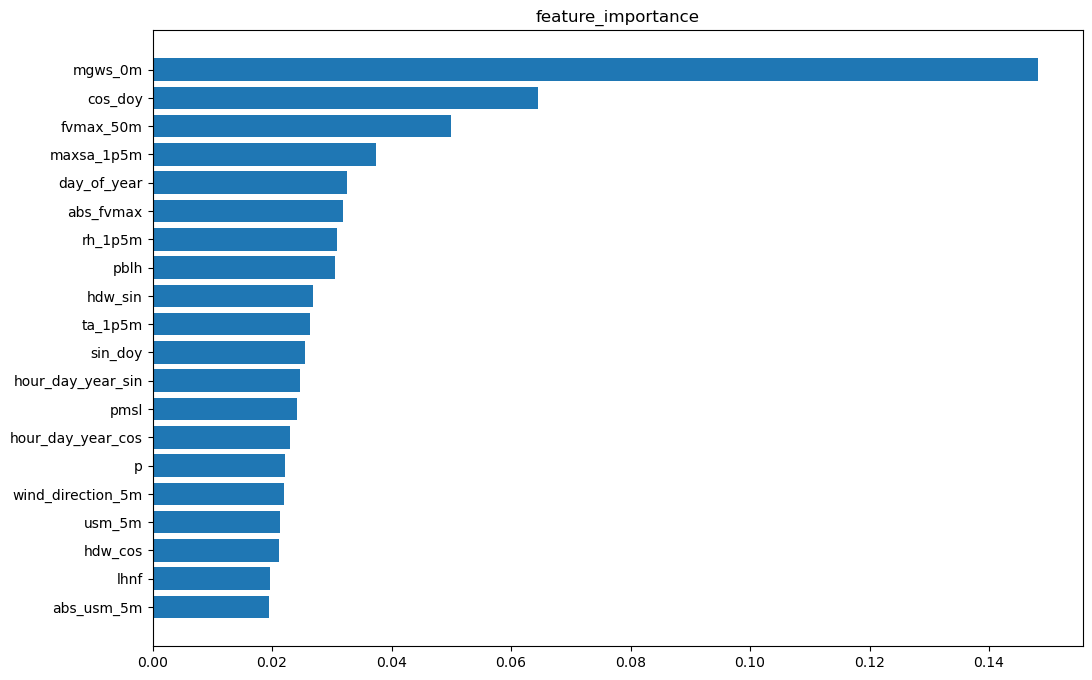

In [15]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
pred_val = rf.predict(X_valid)

importance = rf.feature_importances_
importances = pd.Series(data= importance, index = X_train.columns)
importances.sort_values(inplace= True, ascending= True)
view = importances.tail(20)

plt.figure(figsize = (12,8))
plt.barh(view.index, view)
plt.title("feature_importance")
plt.show()

In [16]:
prediction_val = pd.DataFrame({"pred":pred_val})

y_valid.index = prediction_val.index

def nmae(target, pred_target):
  mae = abs((target - pred_target))/20700
  nmae1 = mae.mean() * 100
  return nmae1

nmae1 = nmae(y_valid["energy_kwh"], prediction_val["pred"])
print(f"NMAE: {nmae1}")


NMAE: 12.700037032086895


In [17]:
target_roll_2024 = target_roll.loc["2020-01-01 01:00:00": "2021-01-01 00:00:00"]
target_roll_2024 = target_roll_2024.fillna(0)

target_roll_2024.index = test_rf.index

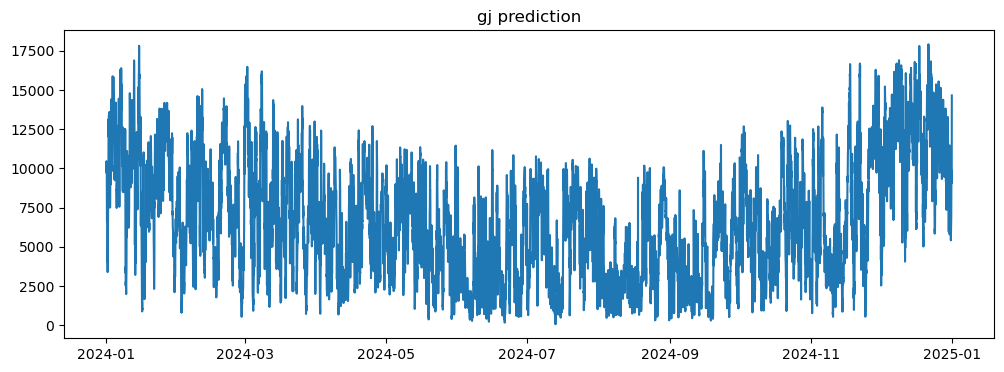

In [18]:
pred = rf.predict(test_gj)
prediction = pd.DataFrame({"pred":pred})
prediction.index = test_gj.index
prediction["pred"] = prediction["pred"] +  target_roll_2024["energy_kwh"]
plt.figure(figsize= (12,4))
plt.plot(prediction.index, prediction["pred"])
plt.title("gj prediction")
plt.show()

In [20]:
prediction.to_csv("경주_모델/경주_예측/경주.csv")

In [ ]:
print("경주 예측 저장 위치: 경주_모델/경주_예측/경주.csv")